In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_screen_time_survey.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   Student_ID  Age Gender  Screen_Time_Hours  Study_Hours  Sleep_Hours  \
0           1   21   Male                NaN          2.6          7.3   
1           2   22   Male                6.6          3.3          6.5   
2           3   20   Male                5.4          7.4          5.0   
3           4   22   Male                2.4          4.4          9.0   
4           5   22   Male                3.2          5.3          6.7   

   Exercise_Hours  Stress_Level  Academic_Score  
0             3.0           5.0            75.8  
1             4.6          10.0            85.7  
2             3.7           4.0            69.8  
3             5.4           9.0            89.1  
4             4.5           6.0            98.0  


In [ ]:
# Display shape
print("\nShape of dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display data types
print("\nData types:")
print(df.dtypes)

# Display information
print("\nDataset Information:")
df.info()


Shape of dataset:
(150, 9)

Column names:
Index(['Student_ID', 'Age', 'Gender', 'Screen_Time_Hours', 'Study_Hours',
       'Sleep_Hours', 'Exercise_Hours', 'Stress_Level', 'Academic_Score'],
      dtype='object')

Data types:
Student_ID             int64
Age                    int64
Gender                object
Screen_Time_Hours    float64
Study_Hours          float64
Sleep_Hours          float64
Exercise_Hours       float64
Stress_Level         float64
Academic_Score       float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         150 non-null    int64  
 1   Age                150 non-null    int64  
 2   Gender             150 non-null    object 
 3   Screen_Time_Hours  145 non-null    float64
 4   Study_Hours        145 non-null    float64
 5   Sleep_Hours        145 non-null

In [ ]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Calculate missing value percentage
print("\nMissing value percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after handling:")
print(df.isnull().sum())
# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


Missing values:
Student_ID           0
Age                  0
Gender               0
Screen_Time_Hours    5
Study_Hours          5
Sleep_Hours          5
Exercise_Hours       0
Stress_Level         5
Academic_Score       0
dtype: int64

Missing value percentage:
Student_ID           0.000000
Age                  0.000000
Gender               0.000000
Screen_Time_Hours    3.333333
Study_Hours          3.333333
Sleep_Hours          3.333333
Exercise_Hours       0.000000
Stress_Level         3.333333
Academic_Score       0.000000
dtype: float64

Missing values after handling:
Student_ID           0
Age                  0
Gender               0
Screen_Time_Hours    0
Study_Hours          0
Sleep_Hours          0
Exercise_Hours       0
Stress_Level         0
Academic_Score       0
dtype: int64

Number of duplicate rows:
0

Shape after removing duplicates:
(150, 9)



Summary Statistics:
       Student_ID         Age  Screen_Time_Hours  Study_Hours  Sleep_Hours  \
count  150.000000  150.000000         150.000000   150.000000   150.000000   
mean    75.500000   20.486667           5.068667     4.473333     7.117333   
std     43.445368    1.661796           1.725223     1.516605     1.131000   
min      1.000000   18.000000           1.200000     1.000000     4.700000   
25%     38.250000   19.000000           3.925000     3.500000     6.425000   
50%     75.500000   21.000000           5.000000     4.500000     7.200000   
75%    112.750000   22.000000           6.100000     5.375000     7.700000   
max    150.000000   23.000000          10.000000     9.000000     9.600000   

       Exercise_Hours  Stress_Level  Academic_Score  
count      150.000000     150.00000      150.000000  
mean         3.115333       5.68000       77.182000  
std          1.553940       2.92483        9.492746  
min          0.000000       1.00000       53.000000  
25%   

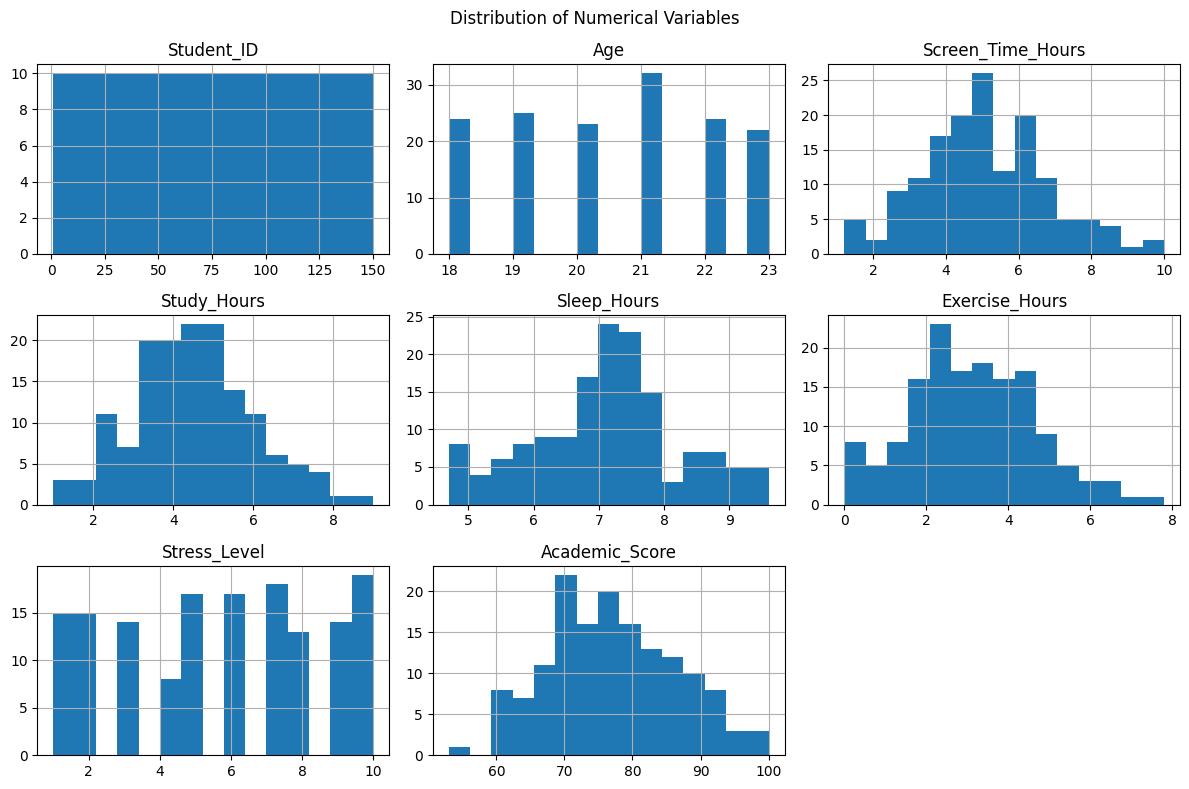

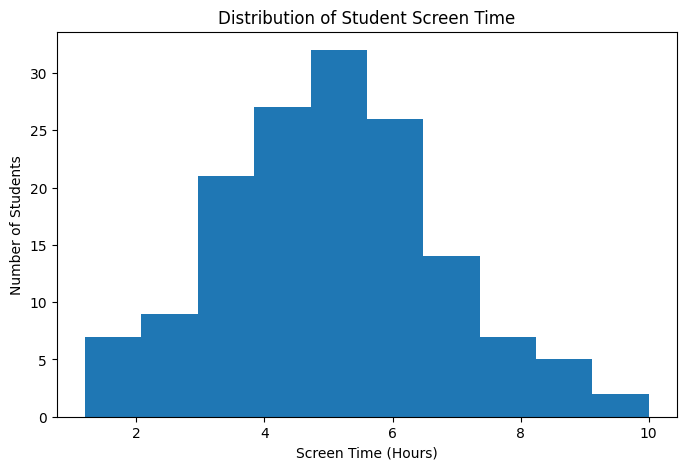

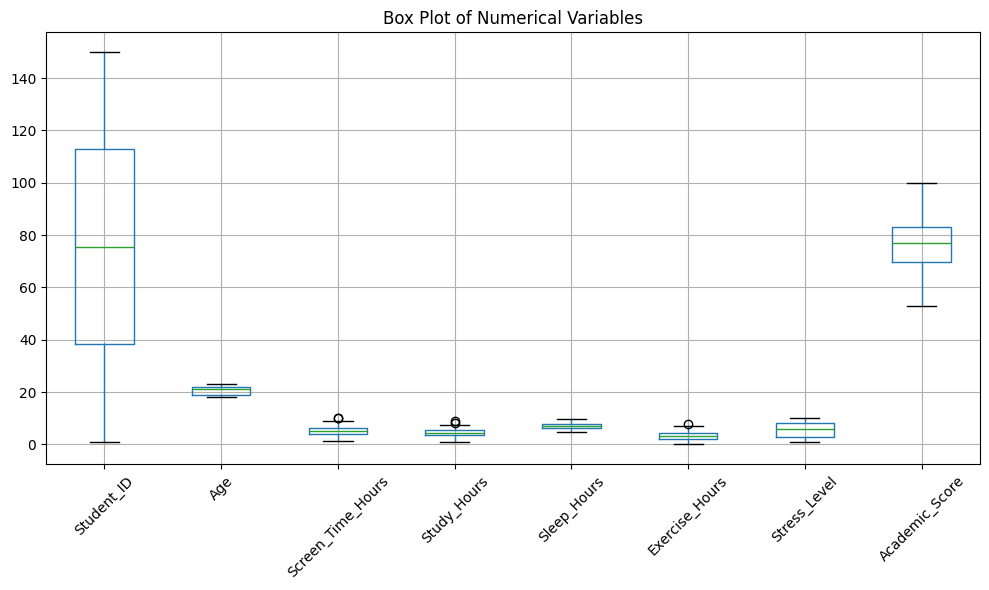

In [ ]:
print("\nSummary Statistics:")
print(df.describe())

# Plot histograms
df[numeric_columns].hist(figsize=(12, 8), bins=15)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(df["Screen_Time_Hours"], bins=10)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Screen Time")

plt.show()
plt.figure(figsize=(10, 6))

df[numeric_columns].boxplot()

plt.title("Box Plot of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Correlation Matrix:
                   Student_ID       Age  Screen_Time_Hours  Study_Hours  \
Student_ID           1.000000 -0.110575           0.035955     0.078930   
Age                 -0.110575  1.000000           0.041171    -0.054999   
Screen_Time_Hours    0.035955  0.041171           1.000000    -0.036591   
Study_Hours          0.078930 -0.054999          -0.036591     1.000000   
Sleep_Hours          0.016814 -0.022730          -0.024347    -0.085339   
Exercise_Hours      -0.024102 -0.040594          -0.178714    -0.016684   
Stress_Level        -0.035017 -0.035404           0.101211    -0.036282   
Academic_Score       0.011109  0.135510           0.017513    -0.064287   

                   Sleep_Hours  Exercise_Hours  Stress_Level  Academic_Score  
Student_ID            0.016814       -0.024102     -0.035017        0.011109  
Age                  -0.022730       -0.040594     -0.035404        0.135510  
Screen_Time_Hours    -0.024347       -0.178714      0.101211      

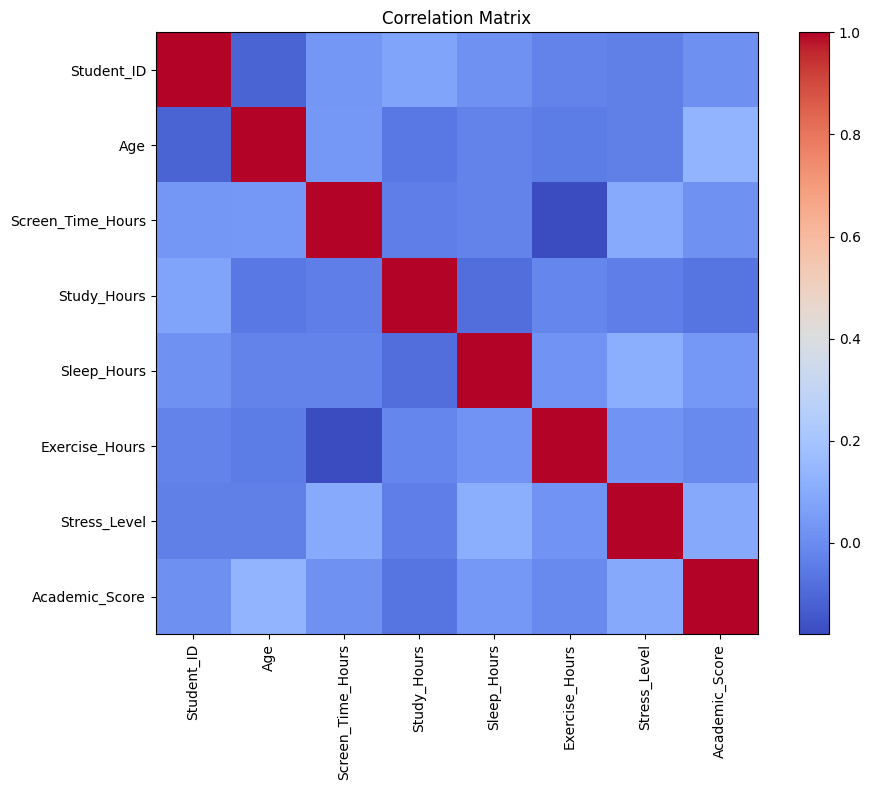

In [ ]:
# Calculate correlation
correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

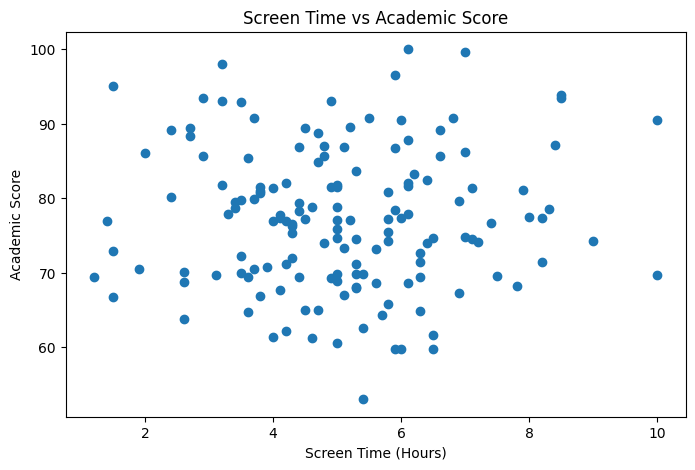

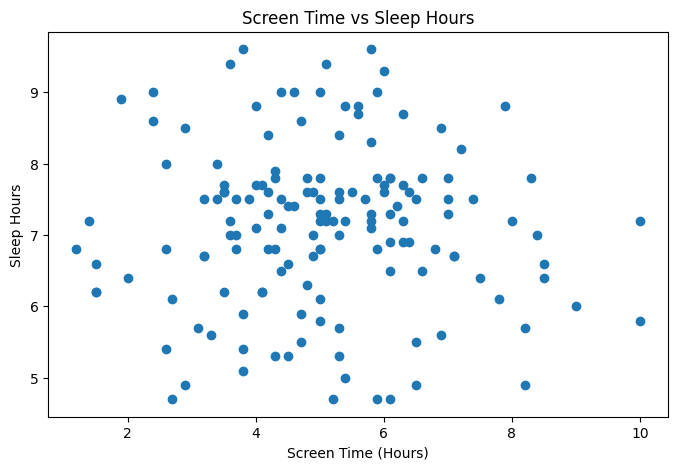

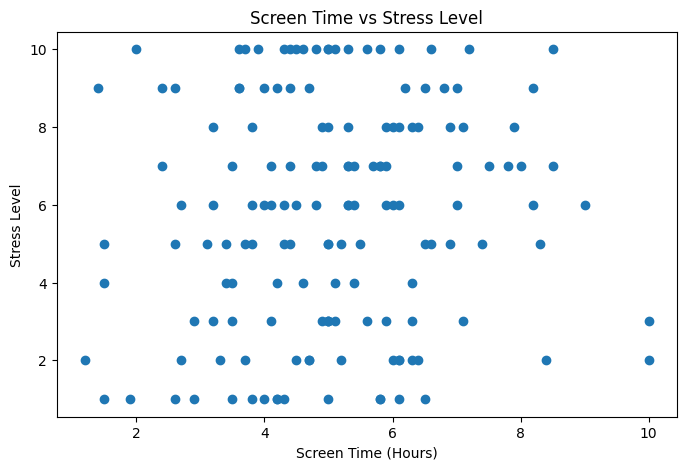


Final cleaned dataset:
   Student_ID  Age Gender  Screen_Time_Hours  Study_Hours  Sleep_Hours  \
0           1   21   Male                5.0          2.6          7.3   
1           2   22   Male                6.6          3.3          6.5   
2           3   20   Male                5.4          7.4          5.0   
3           4   22   Male                2.4          4.4          9.0   
4           5   22   Male                3.2          5.3          6.7   

   Exercise_Hours  Stress_Level  Academic_Score  
0             3.0           5.0            75.8  
1             4.6          10.0            85.7  
2             3.7           4.0            69.8  
3             5.4           9.0            89.1  
4             4.5           6.0            98.0  

Final shape:
(150, 9)


In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Screen_Time_Hours"],
    df["Academic_Score"]
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Academic Score")
plt.title("Screen Time vs Academic Score")

plt.show()
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Screen_Time_Hours"],
    df["Sleep_Hours"]
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Sleep Hours")
plt.title("Screen Time vs Sleep Hours")

plt.show()
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Screen_Time_Hours"],
    df["Stress_Level"]
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Stress Level")
plt.title("Screen Time vs Stress Level")

plt.show()
print("\nFinal cleaned dataset:")
print(df.head())

print("\nFinal shape:")
print(df.shape)